In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('adult.csv') #workclass, occupation has null
df = df.drop(columns=['native.country'])
df = df.replace('?','missing')
df = df.replace('<=50K',0)
df = df.replace('>50K',1)
df['income'] = df['income'].astype(bool)


df = pd.get_dummies(df)
#feature scaling
num_cols = df.select_dtypes(include='int64').columns
df[num_cols] = (df[num_cols] - df[num_cols].mean()) /df[num_cols].std()

bool_cols = df.select_dtypes(include=bool).columns
df[bool_cols] = df[bool_cols].astype(int)

# print(df.select_dtypes(include ='object').nunique())
# print((df['workclass']=='missing').sum()/len(df)*100)
# print((df['occupation']=='missing').sum()/len(df)*100) cant get rid of them more than 5% of our data


C:\Users\HP Pavilion\AppData\Local\Temp\ipykernel_9208\1126443219.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('>50K',1)


In [3]:
print(f"\n  Dataset Shape: {df.shape}")
print(f"   - Total samples: {df.shape[0]}")
print(f"   - Total features: {df.shape[1] - 1} (+ 1 target)")

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📈 Dataset Info:")
print(df.info())

print(f"\n📊 Statistical Summary:")
print(df.describe())


  Dataset Shape: (32561, 67)
   - Total samples: 32561
   - Total features: 66 (+ 1 target)

📋 First 5 rows:
        age    fnlwgt  education.num  capital.gain  capital.loss  \
0  3.769554 -1.067981      -0.420053     -0.145918     10.593344   
1  3.183063 -0.539160      -0.420053     -0.145918     10.593344   
2  2.010079 -0.035219      -0.031360     -0.145918     10.593344   
3  1.130342 -0.468208      -2.363521     -0.145918      9.461719   
4  0.177293  0.709471      -0.031360     -0.145918      9.461719   

   hours.per.week  income  workclass_Federal-gov  workclass_Local-gov  \
0       -0.035429       0                      0                    0   
1       -1.817176       0                      0                    0   
2       -0.035429       0                      0                    0   
3       -0.035429       0                      0                    0   
4       -0.035429       0                      0                    0   

   workclass_Never-worked  ...  relationsh


📊 Target Distribution:
   - Under equal 50k (0): 24720 person (75.9%)
   - Over 50K (1): 7841 person (24.1%)


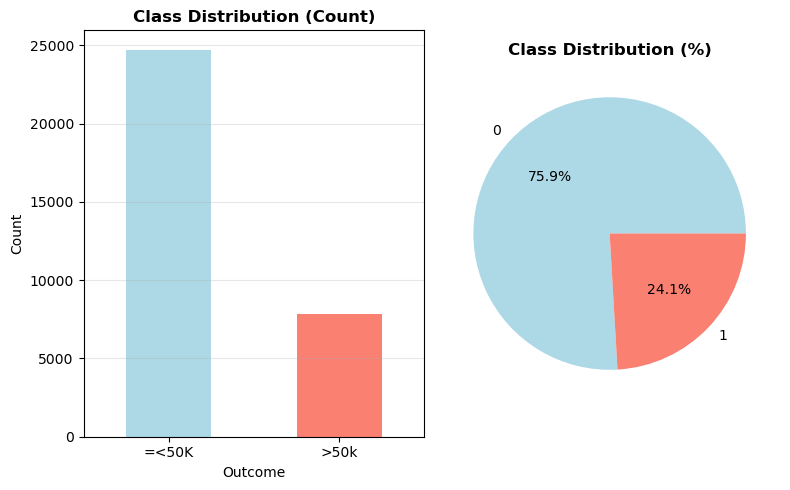

In [4]:
outcome_counts = df['income'].value_counts()
print(f"\n📊 Target Distribution:")
print(f"   - Under equal 50k (0): {outcome_counts[0]} person ({outcome_counts[0]/len(df)*100:.1f}%)")
print(f"   - Over 50K (1): {outcome_counts[1]} person ({outcome_counts[1]/len(df)*100:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
df['income'].value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Class Distribution (Count)', fontsize=12, fontweight='bold')
plt.xlabel('Outcome', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.xticks([0, 1], ['=<50K', '>50k'], rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df['income'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Class Distribution (%)', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [5]:
def sigmoid(z):
    """
    Sigmoid activation function
    Formula: σ(z) = 1 / (1 + e^(-z))
    
    Maps any real number to range (0, 1)
    Used to convert linear output to probability
    """
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, theta, bias):
    """
    Binary Cross-Entropy Loss (Log Loss)
    
    Formula: J = -1/m * Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
    
    Parameters:
    - X: Feature matrix (m samples, n features)
    - y: True labels (m samples)
    - theta: Feature weights (n features)
    - bias: Bias term (scalar)
    
    Returns:
    - cost: Average loss across all samples
    """
    m = len(y)
    
    # Forward pass: Predictions
    z = np.dot(X, theta) + bias
    predictions = sigmoid(z)
    
    # Avoid log(0) by clipping predictions
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon) #avoiding overflow and underflow
    
    # Binary cross-entropy loss
    cost = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    
    return cost

def gradient_descent(X, y, theta, bias, learning_rate):
    """
    One step of Gradient Descent
    
    Updates weights using gradients:
    - ∂J/∂w = 1/m * X^T * (ŷ - y)
    - ∂J/∂b = 1/m * Σ(ŷ - y)
    
    Parameters:
    - X: Feature matrix
    - y: True labels
    - weights: Current weights
    - bias: Current bias
    - learning_rate: Step size
    
    Returns:
    - updated_weights, updated_bias
    """
    m = len(y)
    
    # Forward pass
    z = (np.dot(X, theta) + bias).astype('int64')
    predictions = sigmoid(z)
    
    # Compute gradients
    dw = (1/m) * np.dot(X.T, (predictions - y))
    db = (1/m) * np.sum(predictions - y)
    
    # Update parameters
    theta = theta - learning_rate * dw
    bias = bias - learning_rate * db
    
    return theta, bias

def accuracy_score (real_value ,pred_value):
    
    check = (real_value == pred_value)
    correct_pred = check.sum()
    
    total_pred = len(real_value)
    accuracy = correct_pred / total_pred
    
    return accuracy



In [6]:
def train_logistic_regression(X, y, learning_rate=0.01, num_epochs=1000, verbose=True):
    """
    Train Logistic Regression using Gradient Descent
    
    Parameters:
    - X: Training features
    - y: Training labels
    - learning_rate: Learning rate for gradient descent
    - num_epochs: Number of training iterations
    - verbose: Print progress
    
    Returns:
    - weights, bias, history (costs and accuracies over epochs)
    """
    m, n = X.shape
    
    # Initialize parameters
    weights = np.zeros(n)
    bias = 0
    
    # History tracking
    cost_history = []
    accuracy_history = []
    
    # Training loop
    for epoch in range(num_epochs):
        # Perform gradient descent
        weights, bias = gradient_descent(X, y, weights, bias, learning_rate)
        
        # Compute cost
        cost = compute_cost(X, y, weights, bias)
        cost_history.append(cost)
        
        # Compute accuracy
        z = np.dot(X, weights) + bias
        predictions = sigmoid(z)
        y_pred = (predictions >= 0.5).astype(int) #returns a df with int type
        accuracy = np.mean(y_pred == y)
        accuracy_history.append(accuracy)
        
        # Print progress
        if verbose and (epoch + 1) % 100 == 0:
            print(f"   Epoch {epoch+1:4d}/{num_epochs}: Cost = {cost:.4f}, Accuracy = {accuracy:.4f}")
    
    return weights, bias, cost_history, accuracy_history
def train_test_split_scratch(X, y, test_size=0.2, random_seed=42):
    """
    Split data into training and test sets (from scratch, no sklearn).
    
    Parameters:
    - X: Features, shape (m, n)
    - y: Labels (integer), shape (m,)
    - y_onehot: One-hot encoded labels, shape (m, K)
    - test_size: Fraction of data for testing (0.0 to 1.0)
    - random_seed: For reproducibility
    
    Returns:
    - X_train, X_test, y_train, y_test, y_train_onehot, y_test_onehot
    """
    np.random.seed(random_seed)
    
    m = X.shape[0]
    indices = np.arange(m)
    np.random.shuffle(indices)  # Shuffle indices randomly
    
    # Calculate split point
    test_count = int(m * test_size)
    
    # Split indices
    test_indices = indices[:test_count]
    train_indices = indices[test_count:]
    
    # Split data
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

In [7]:
def predict(X, weights, bias):
    """
    Make predictions using trained model
    
    Returns:
    - predictions: Binary predictions (0 or 1)
    - probabilities: Probability estimates
    """
    z = np.dot(X, weights) + bias
    probabilities = sigmoid(z)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions, probabilities

In [8]:
# Separate features and target
X = df.drop(columns=['income']).values
y = df['income'].values

# Train-test split
# row_count = len(X)
# eighty = int(0.8*row_count)

# X_train = X[:eighty]
# X_test= X[eighty+1:row_count]
# y_train= y[:eighty]
# y_test = y[eighty+1:row_count]

X_train, X_test, y_train, y_test = train_test_split_scratch(
    X, y, test_size=0.2, random_seed=43
)

print(f"\n✂️  Train-Test Split:")
print(f"   - Training: {X_train.shape[0]} samples")
print(f"   - Test: {X_test.shape[0]} samples")




✂️  Train-Test Split:
   - Training: 26049 samples
   - Test: 6512 samples



🔧 Configuration:
   - Learning Rate: 0.1 (LARGE, because features are scaled!)
   - Epochs: 1000
   - Data: SCALED (mean=0, std=1)

🚀 Training started...

   Epoch  100/1000: Cost = 0.3756, Accuracy = 0.8191
   Epoch  200/1000: Cost = 0.3560, Accuracy = 0.8332
   Epoch  300/1000: Cost = 0.3493, Accuracy = 0.8361
   Epoch  400/1000: Cost = 0.3451, Accuracy = 0.8387
   Epoch  500/1000: Cost = 0.3419, Accuracy = 0.8411
   Epoch  600/1000: Cost = 0.3395, Accuracy = 0.8429
   Epoch  700/1000: Cost = 0.3375, Accuracy = 0.8438
   Epoch  800/1000: Cost = 0.3358, Accuracy = 0.8446
   Epoch  900/1000: Cost = 0.3345, Accuracy = 0.8459
   Epoch 1000/1000: Cost = 0.3334, Accuracy = 0.8467

✅ Training complete!

RESULTS WITH SCALING:

📊 Final Accuracies:
   - Training Accuracy: 0.8467 (84.67%)
   - Test Accuracy:     0.8414 (84.14%)
   - Final Cost:        0.3334

🔍 Learned Weights:
   - age                      :   0.4244
   - fnlwgt                   :   0.0935
   - education.num            :   0

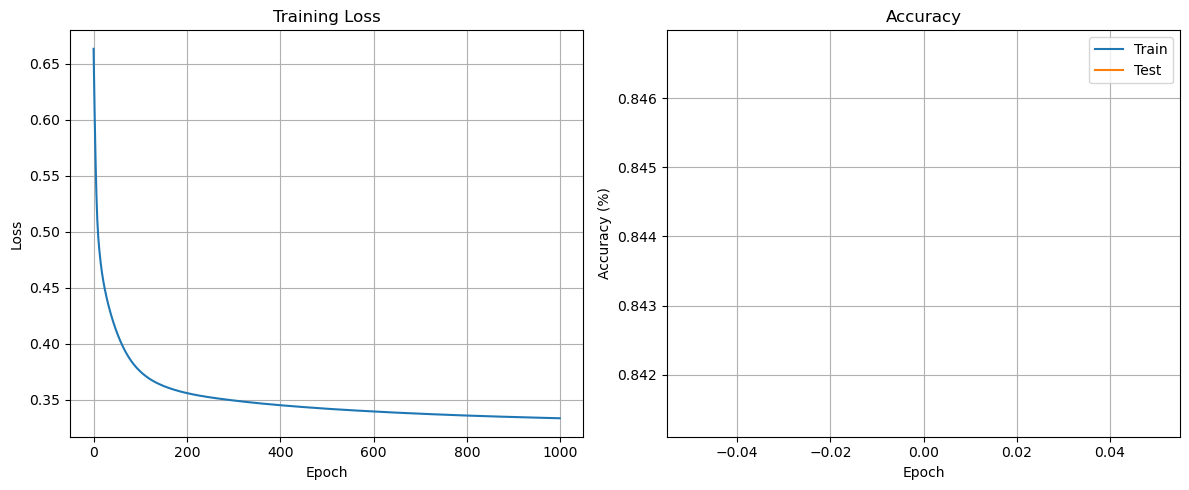

In [12]:
print("\n🔧 Configuration:")
print("   - Learning Rate: 0.1 (LARGE, because features are scaled!)")
print("   - Epochs: 1000")
print("   - Data: SCALED (mean=0, std=1)")

print("\n🚀 Training started...\n")

weights_with_scale, bias_with_scale, cost_history_with_scale, acc_history_with_scale = train_logistic_regression(
    X_train, y_train,
    learning_rate=0.1,  # Much larger LR works with scaled data!
    num_epochs=1000,
    verbose=True
)

print("\n✅ Training complete!")

# Make predictions
train_pred_with_scale, train_prob_with_scale = predict(X_train, weights_with_scale, bias_with_scale)
test_pred_with_scale, test_prob_with_scale = predict(X_test , weights_with_scale, bias_with_scale)

# Calculate accuracies
train_acc_with_scale = accuracy_score(y_train, train_pred_with_scale)
test_acc_with_scale = accuracy_score(y_test, test_pred_with_scale)

print("\n" + "="*70)
print("RESULTS WITH SCALING:")
print("="*70)
print(f"\n📊 Final Accuracies:")
print(f"   - Training Accuracy: {train_acc_with_scale:.4f} ({train_acc_with_scale*100:.2f}%)")
print(f"   - Test Accuracy:     {test_acc_with_scale:.4f} ({test_acc_with_scale*100:.2f}%)")
print(f"   - Final Cost:        {cost_history_with_scale[-1]:.4f}")

print(f"\n🔍 Learned Weights:")
feature_names = df.drop(columns='income')
for name, weight in zip(feature_names, weights_with_scale):
    print(f"   - {name:25s}: {weight:8.4f}")
print(f"   - Bias:                     {bias_with_scale:8.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(cost_history_with_scale)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_acc_with_scale, label="Train")
plt.plot(test_acc_with_scale, label="Test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

